# Homogeneous BRDF distribution heatmap

Estimation using Metropolis-Hastings without gradient

(grayscale / microfacet)

Experiment #2: highlight not visible

### Scene setup

In [1]:
import ivt
from ivt.scene import Scene, DiffuseBRDF, MicrofacetBRDF, Mesh, \
    PerspectiveCamera, HDRFilm, Integrator, EnvironmentLight
from ivt.io import read_image, read_mesh, write_image

In [2]:
import torch

In [3]:
scene = Scene()
diffuse = 0.3
specular = 0.3
roughness = 0.3
black = (0,0,0)
scene.set('mat', MicrofacetBRDF(diffuse, specular, roughness))
scene.set('black', DiffuseBRDF(black))
scene.set('mesh1', Mesh.from_file("quad.obj", 'mat')) # surface to reconstruct
scene.set('mesh2', Mesh.from_file("light.obj", 'black', radiance=400)) # area light source
scene.set('film', HDRFilm(256, 256))
scene.set('integrator', Integrator('path', {'max_depth': 3, 'hide_emitters': True}))
scene.set('cam1', PerspectiveCamera.from_lookat(fov=26, origin=(5,1.8,0), target=(0,0,0), up=(0,1,0))) # camera

In [4]:
renderer = ivt.renderer.Renderer(connector_name='psdr_jit', render_options = {
    "spp": 1,
    "sppe": 0,
    "sppse": 0,
    "npass": 1,
    "log_level": 0
})
# because ivt has a glitch that doesn't allow changing spp, workaround here to render a 128-spp target image
# I_t = renderer(scene)
I_t = torch.cat([renderer(scene) for _ in range(128)]).mean(axis=0).unsqueeze(dim=0)

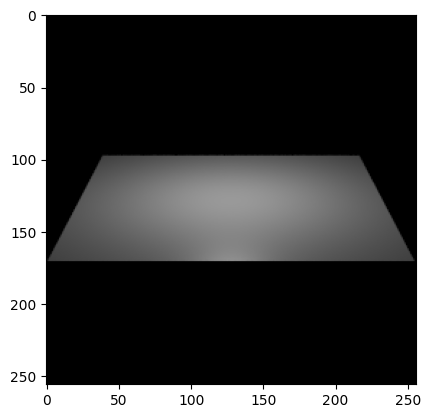

In [5]:
# Visualize the target Image
from matplotlib import pyplot as plt
def showimg(I):
    plt.imshow((I**0.454).detach().cpu().numpy().squeeze(), vmax=1)
def showhist(a):
    plt.hist(a.view(-1).detach().cpu().numpy(), bins=100)
showimg(I_t)

### Parameter Mapping & Prior Distribution

To make sure parameters are in proper range and avoid dealing with clipping samples, we map parameters from a finite range into the entire real number range. Specifically in this experiment, the *original parameters* are all in range (0,1) denoted as x. We map them into (-inf,inf) using the formula y=logit(x). Invert it, we have x=sigmoid(y). We call y *normalized parameter*.

We're assuming uniform prior distribution in the parametric space x~U[0,1]. After the inverse sigmoid mapping, the prior distribution in (-inf,inf) should be pdf(y) = x*(1-x) = sigmoid(y) * (1-sigmoid(y)).

Note that for numerical stability and convenience for sampling, all pdfs are represented as -log(pdf).

In [6]:
# To avoid clipping, we are mapping parameters from a finite range (0,1) to (-inf,inf)
def orig_to_norm(x):
    return torch.log(x/(1-x))

def norm_to_orig(y):
    return torch.sigmoid(y)

In [7]:
def logpdf_prior(x): # here x is normalized parameter (tensor)
    xo = norm_to_orig(x)
    return -(xo * (1-xo)).log().sum(axis=-1) # multiplied over all channels

### Loss Function (Likelihood)

Because we're reconstructing the texture for an exact match, we can simply use per-pixel loss in the image space.

In [8]:
def logpdf(img):
    from math import sqrt, pi
    sigma = torch.tensor(0.02)
    # log of density of a normal distribution
    lpdf = ((img - I_t).pow(2.0)/(2.0*sigma.pow(2.0)) + \
                (sqrt(2*pi)*sigma).log()).mean()
    return lpdf

### Posterior Probability

In [9]:
def U_orig(xo):
    scene['mat']['d'] = xo[0]
    scene['mat']['s'] = xo[1]
    scene['mat']['r'] = xo[2]
    img = renderer(scene)
    lpdf = logpdf(img)
    return lpdf, img

# potential energy in the normalized parametric space
def U(x):
    scene['mat']['d'] = norm_to_orig(x[0])
    scene['mat']['s'] = norm_to_orig(x[1])
    scene['mat']['r'] = norm_to_orig(x[2])
    img = renderer(scene)
    lpdf = logpdf(img) + logpdf_prior(x)
    return lpdf, img

In [10]:
from tqdm import tqdm
import time
from torch.distributions import Normal

In [11]:
# compute posterior probability on a regular 3D grid
import itertools
res = 24
grid = itertools.product(range(24), repeat=3)
Us = []
for i,j,k in tqdm(grid):
    x = (i+0.5)/res
    y = (j+0.5)/res
    z = (k+0.5)/res
    u = U_orig(torch.tensor([x,y,z]).cuda())[0].cpu()
    u = (-u).exp()
    Us.append(u)

13824it [04:01, 57.26it/s]


In [12]:
Us = torch.tensor(Us).reshape((res, res, res))

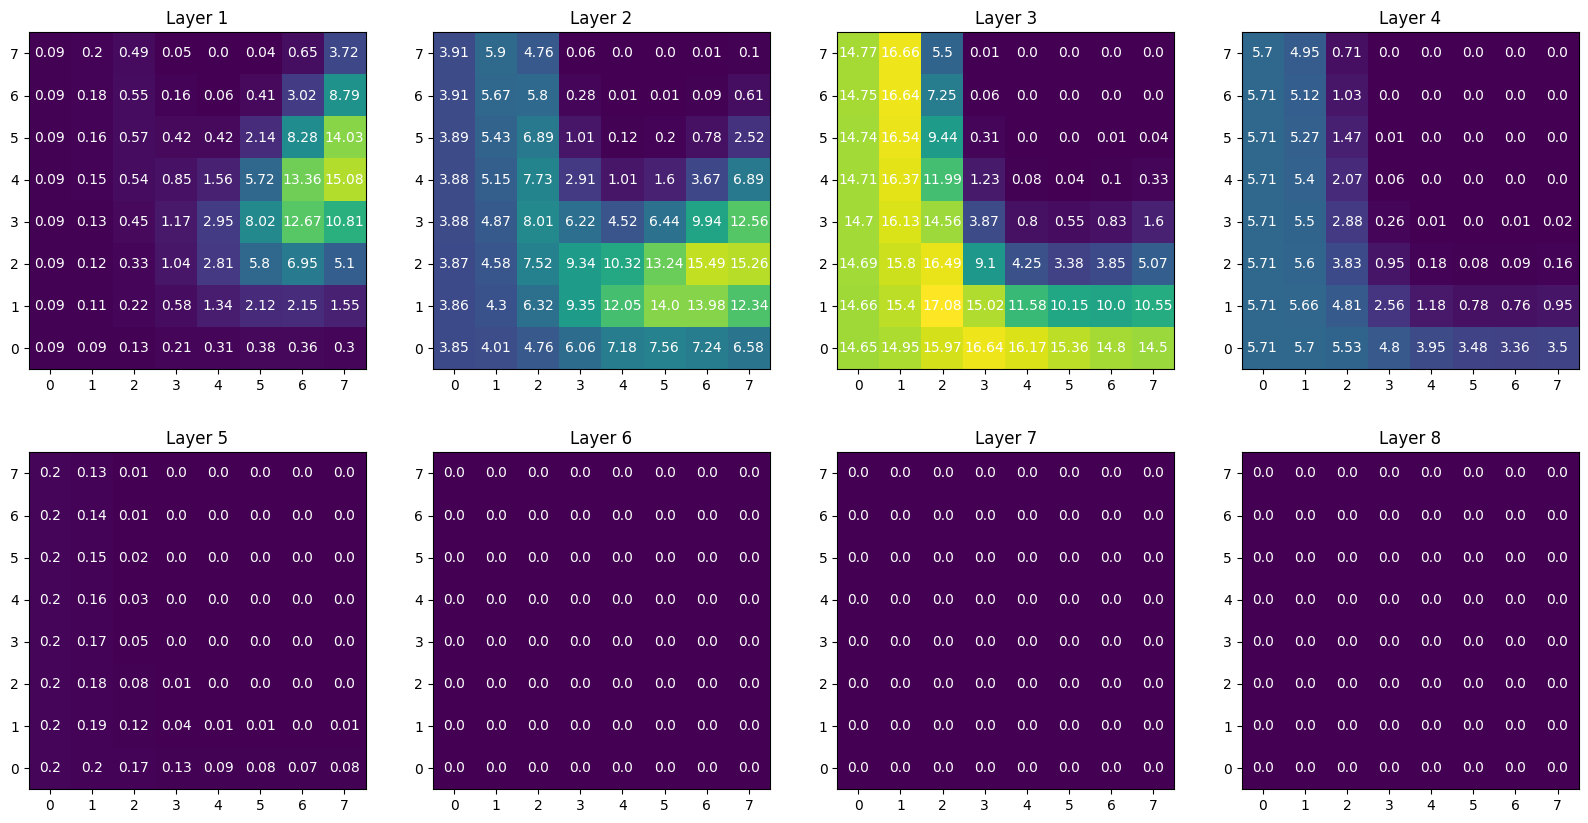

In [13]:
def block_avg(tensor, block_size):
    # Unfold the tensor into blocks
    tensor_unfold = tensor.unfold(0, block_size[0], block_size[0]).unfold(1, block_size[1], block_size[1]).unfold(2, block_size[2], block_size[2])
    # Compute the mean over the block dimensions
    return tensor_unfold.mean(dim=[-1, -2, -3])

reduced_us = block_avg(Us, (3,3,3))

vmin = reduced_us.numpy().min()
vmax = reduced_us.numpy().max()

# slive over x-axis (diffuse)

fig, axs = plt.subplots(2, 4, figsize=(20, 10))

for i0 in range(2):
    for i1 in range(4):
        i = i0*4+i1
        im = axs[i0][i1].imshow(reduced_us[i].numpy(), interpolation='nearest', origin='lower', vmin=vmin, vmax=vmax)
        axs[i0][i1].set_title(f'Layer {i+1}')
        # Loop over data dimensions and create text annotations.
        for j in range(8):
            for k in range(8):
                text = axs[i0][i1].text(k, j, round(reduced_us[i, j, k].item(), 2),
                                   ha="center", va="center", color="w")

plt.show()

In [14]:
# 3D plotting using mayavi
from mayavi import mlab

In [15]:
%gui qt

In [21]:
import numpy as np
# Create some test data
x, y, z = np.ogrid[0.5/res:1-0.5/res:1j*res, .5/res:1-0.5/res:1j*res, .5/res:1-0.5/res:1j*res]
s = Us.numpy()

In [24]:
vol = mlab.pipeline.volume(mlab.pipeline.scalar_field(s))
mlab.axes(xlabel='x', ylabel='y', zlabel='z', ranges=[0,1,0,1,0,1], nb_labels=5)

mlab.outline(vol)

### Metropolis-Hastings

In [113]:
class MH:
    def __init__(self):
        self.num_accepts = 0
        self.num_rejects = 0
        self.xs = []
        self.Us = []
    
    def proposal(self, x0, U0):
        distr = Normal(x0, 0.9)
        x_tmp = distr.sample()
        U_tmp, _ = U(x_tmp)
        arej = torch.exp((U0-U_tmp).clamp(max=88))
        return arej, x_tmp, U_tmp

    def sample(self, x0, nsamples=1000):
        U0, _ = U(x0)
        for i in tqdm(range(nsamples)):
            # generate proposal sample
            arej, x_tmp, U_tmp = self.proposal(x0, U0)
            # accept or reject proposal on a per-pixel basis
            accepts = torch.bernoulli(arej.clamp_max(1)).bool()
            self.num_accepts += accepts
            if accepts:
                x0 = x_tmp
                U0 = U_tmp
#             x0 = torch.where(accepts.unsqueeze(-1), x_tmp, x0).detach()
            self.xs.append(x0)
            self.Us.append(U0)

In [123]:
mcmc = MH()

x0 = orig_to_norm(torch.zeros((3)).cuda().uniform_(0, 1))
mcmc.sample(x0, nsamples=1000000)

 25%|█████████████████▍                                                   | 252788/1000000 [1:13:40<3:37:45, 57.19it/s]


RuntimeError: jit_new_cse_scope(): overflow (scope index exceeds the 24 bit counter of the Variable data structure)!

In [126]:
len(mcmc.xs)

252788

In [127]:
mcmc.num_accepts

tensor(90146, device='cuda:0')

In [128]:
def count_vectors(vectors, grid_size=8):
    # First, multiply the vectors by the grid size, and then floor them
    # This will effectively sort them into the grid
    vectors = torch.floor(vectors * grid_size).long()

    # Ensure all vectors are within the valid range
    vectors = vectors.clamp(max=grid_size-1)

    # Create an empty tensor to hold the counts
    counts = torch.zeros((grid_size, grid_size, grid_size))

    # Iterate over the vectors and increment the appropriate count
    for vector in vectors:
        x, y, z = vector
        counts[x, y, z] += 1

    return counts

counts = count_vectors(norm_to_orig(torch.stack(mcmc.xs)))

In [129]:
# counts *= 8*8*8/50000

In [130]:
def show_heatmap(grids):
    vmin = grids.numpy().min()
    vmax = grids.numpy().max()

    fig, axs = plt.subplots(2, 4, figsize=(20, 10))

    for i0 in range(2):
        for i1 in range(4):
            i = i0*4+i1
            im = axs[i0][i1].imshow(grids[i].numpy(), interpolation='nearest', origin='lower', vmin=vmin, vmax=vmax)
            axs[i0][i1].set_title(f'Layer {i+1}')
            # Loop over data dimensions and create text annotations.
#             for j in range(8):
#                 for k in range(8):
#                     text = axs[i0][i1].text(k, j, round(grids[i, j, k].item(), 2),
#                                        ha="center", va="center", color="w")
    plt.show()

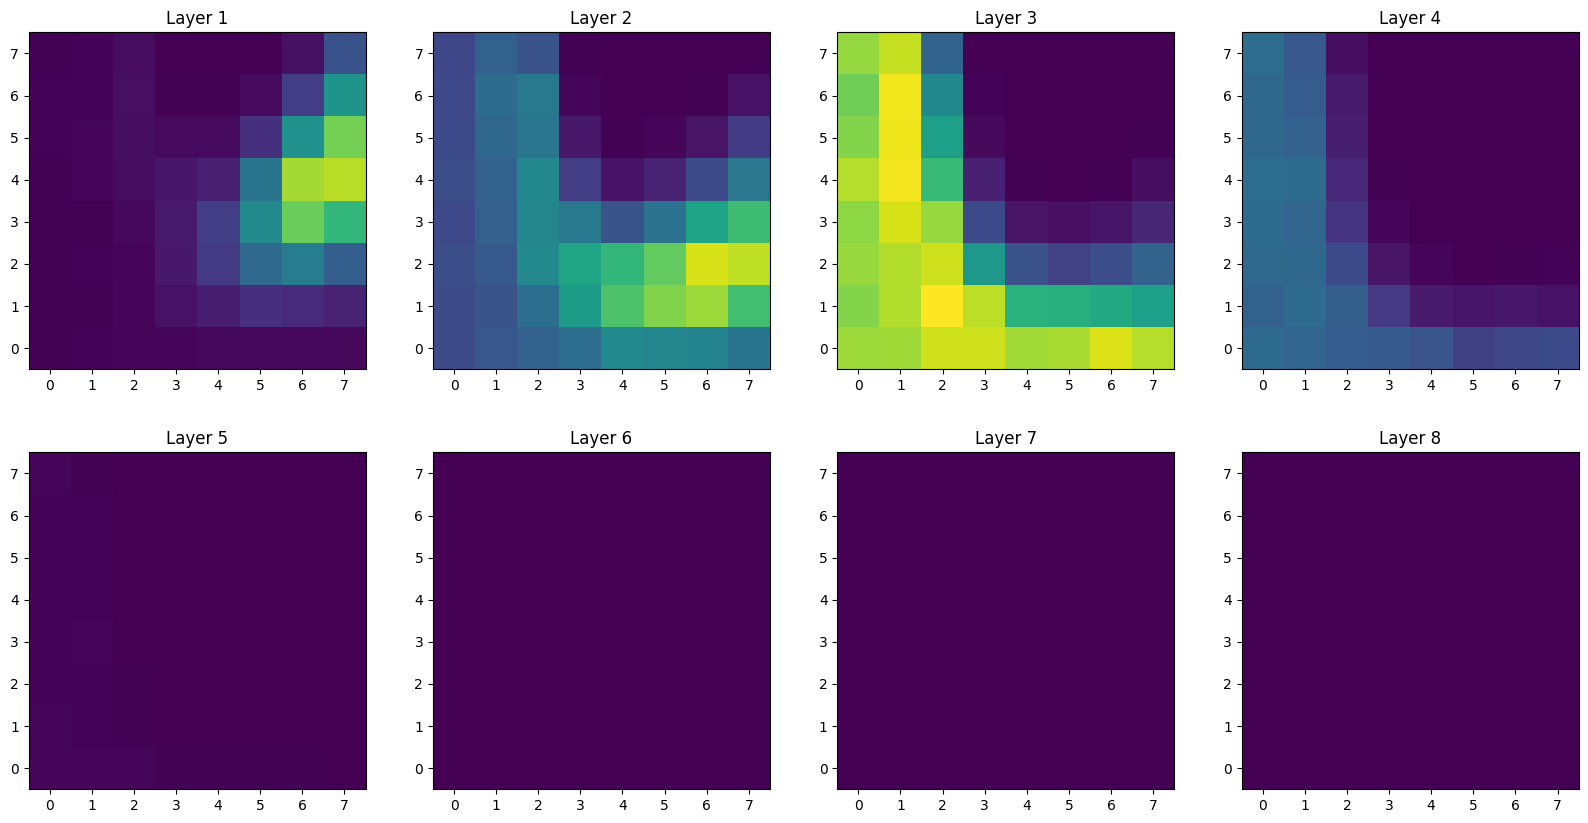

In [131]:
show_heatmap(counts)

In [122]:
# show_heatmap(counts.permute(1,0,2))